In [68]:
!pip install matplotlib scikit-learn joblib pandas numpy

In [69]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Load NASA C-MAPSS Dataset

The dataset contains aircraft engine sensor readings over time.
Each engine has multiple operating cycles until failure.

In [70]:
import os

data_path = "../data/CMAPSSData"
print(os.listdir(data_path))

['Damage Propagation Modeling.pdf', 'readme.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']


In [71]:
train_path = os.path.join(data_path, "train_FD001.txt")

df = pd.read_csv(train_path, sep=" ", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [72]:
df.shape

(20631, 28)

In [73]:
df.columns = ["unit", "cycle", "setting_1", "setting_2", "setting_3"] + [
    f"sensor_{i}" for i in range(1, 24)
]

df.head()

,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit       20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

Data Understanding / Exploratory Data Analysis (EDA)

In [75]:
print(df.describe())

               unit         cycle     setting_1     setting_2  setting_3  \
count  20631.000000  20631.000000  20631.000000  20631.000000    20631.0   
mean      51.506568    108.807862     -0.000009      0.000002      100.0   
std       29.227633     68.880990      0.002187      0.000293        0.0   
min        1.000000      1.000000     -0.008700     -0.000600      100.0   
25%       26.000000     52.000000     -0.001500     -0.000200      100.0   
50%       52.000000    104.000000      0.000000      0.000000      100.0   
75%       77.000000    156.000000      0.001500      0.000300      100.0   
max      100.000000    362.000000      0.008700      0.000600      100.0   

       sensor_1      sensor_2      sensor_3      sensor_4      sensor_5  ...  \
count  20631.00  20631.000000  20631.000000  20631.000000  2.063100e+04  ...   
mean     518.67    642.680934   1590.523119   1408.933782  1.462000e+01  ...   
std        0.00      0.500053      6.131150      9.000605  1.776400e-15  ..

## Observations

- `cycle`: min = 1, max = 362, mean ≈ 108.8 → engines operate for different durations.
- `setting_3`: constant value (100), std = 0 → no variation.
- Some sensors have std = 0 → no useful information.
- `sensor_22` and `sensor_23` are completely missing.
- Sensor values have different ranges → scaling may be needed.

## Step 2: Compute Remaining Useful Life (RUL)

**Question:** For each row (engine + cycle), how many cycles are left before that engine fails?

**Approach:** Each engine runs until it fails at its last recorded cycle. So for every row, RUL = (that engine's max cycle) - (current cycle). We find the max cycle per engine with groupby, merge it back onto every row, then subtract.

In [76]:
# Find the last cycle each engine reached (its failure point)
max_cycles = df.groupby("unit")["cycle"].max().reset_index()
max_cycles.columns = ["unit", "max_cycle"]

# Attach that max cycle to every row belonging to that engine
df = df.merge(max_cycles, on="unit")

# RUL(Remaining Useful Life) = how many cycles remain until failure
df["RUL"] = df["max_cycle"] - df["cycle"]

df[["unit", "cycle", "max_cycle", "RUL"]].head(10)

,unit,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


**Observation:** RUL starts at max_cycle - 1 for the first cycle and decreases by 1 each cycle, reaching 0 at the engine's final cycle. Confirms the target is computed correctly — a clean linear countdown per engine.

In [77]:
df["RUL_capped"] = df["RUL"].clip(upper=125)

In [78]:
df[["unit", "cycle", "RUL", "RUL_capped"]].head(15)

,unit,cycle,RUL,RUL_capped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


In [79]:
df[df["unit"] == 1][["cycle", "RUL", "RUL_capped"]].tail(15)

,cycle,RUL,RUL_capped
177,178,14,14
178,179,13,13
179,180,12,12
180,181,11,11
181,182,10,10
182,183,9,9
183,184,8,8
184,185,7,7
185,186,6,6
186,187,5,5


In [80]:
cols_to_drop = ["sensor_1", "sensor_5", "sensor_18", "sensor_19", "sensor_22", "sensor_23"]
df = df.drop(columns=cols_to_drop)

In [81]:
df.shape

(20631, 25)

In [82]:
df.columns.tolist()

['unit',
 'cycle',
 'setting_1',
 'setting_2',
 'setting_3',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_20',
 'sensor_21',
 'max_cycle',
 'RUL',
 'RUL_capped']

## Train/Test Split

Goal:
Separate engines into training and testing groups to avoid data leakage.

In [83]:
unit_ids = df["unit"].unique()

In [84]:
train_ids, test_ids = train_test_split(unit_ids, test_size=0.2, random_state=42)

In [85]:
train_df = df[df["unit"].isin(train_ids)]
test_df = df[df["unit"].isin(test_ids)]

In [86]:
train_df.shape, test_df.shape

((16561, 25), (4070, 25))

In [87]:
drop_cols = ["unit", "cycle", "max_cycle", "RUL", "RUL_capped"]

In [88]:
X_train = train_df.drop(columns=drop_cols)
y_train = train_df["RUL_capped"]
X_test = test_df.drop(columns=drop_cols)
y_test = test_df["RUL_capped"]
X_train.shape, X_test.shape

((16561, 20), (4070, 20))

In [89]:
scaler = StandardScaler()

In [90]:
X_train_scaled = scaler.fit_transform(X_train)

In [91]:
X_test_scaled = scaler.transform(X_test)

In [92]:
model = LinearRegression()

In [93]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
y_pred = model.predict(X_test_scaled)

In [95]:
#this calculate average size of error between what the model predicted and real value
mae = mean_absolute_error(y_test, y_pred)

In [96]:
#MSE squares each error before averaging, which punishes big mistakes more than small ones. RMSE just brings that back to the original units (by taking the square root) so it's easier to compare to MAE. RMSE will usually be a bit bigger than MAE — a big gap between them means you have some large individual errors.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [97]:
#this tells you what fraction of the pattern in the real data your model actually captured, on a scale from 0 to 1 (it can go negative if the model is worse than just guessing the average every time). 0.8 means the model explains 80% of the variation in the data.
r2 = r2_score(y_test, y_pred)

In [98]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

MAE: 16.48
RMSE: 20.41
R2: 0.76




**MAE (Mean Absolute Error) — 16.48**
- Averages the absolute difference between predicted and real values, treating every error equally (a big miss and a small miss are weighted the same per unit).
- Easy to explain to non-technical people: "on average, the model is off by ~16 cycles of remaining useful life."
- Use it when you want a simple, robust sense of typical error size, and you don't want a few extreme mistakes to dominate the picture.

**RMSE (Root Mean Squared Error) — 20.41**
- Squares the errors before averaging, so large mistakes get punished much more than small ones, then takes the square root to bring it back to the original units.
- Because RMSE (20.41) is noticeably higher than MAE (16.48), that gap tells you the model has some predictions that are way off, not just a lot of small consistent errors.
- Use it when large errors are more costly in practice (e.g., missing a real engine failure badly is worse than being slightly off every time).

**R² (R-squared) — 0.76**
- Not an error size — it's a "how much of the pattern did the model capture" score from 0 to 1 (can go negative if the model is bad).
- 0.76 means your model explains about 76% of the variation in remaining useful life. That's a solid start, not great — there's real room to improve.

**Which is "better"?**
There's no single "better" — they answer different questions:
- MAE/RMSE tell you the *size* of your error, in the same units as your target.
- R² tells you the *proportion of variance explained*, unitless — good for comparing models quickly.
- The MAE vs RMSE gap (16.48 vs 20.41) is itself useful diagnostic info: it flags that Linear Regression is missing badly on some cases, which is common when the real degradation pattern is non-linear — exactly what Random Forest tends to handle better.

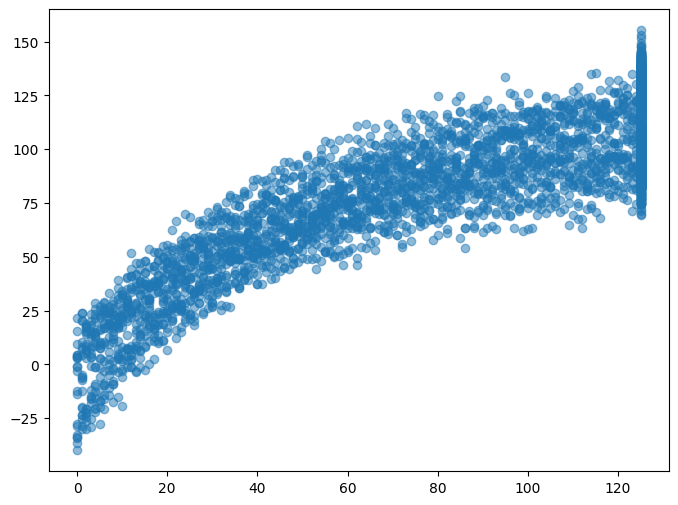

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5) #scatter=> draw dots, every sample of test data show as point
#every point =>(actual RUL, predicted RUL)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted Remaining Useful Life")
plt.show()

this opens a new plot and draws one dot for every test sample, where the x-position is the real remaining useful life and the y-position is what the model predicted. alpha=0.5 makes the dots semi-transparent so you can see where they overlap/cluster.

In [103]:
#Train a Random Forest as comparison. Same data, different model.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [104]:
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [105]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [106]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2: {r2_rf:.2f}")

MAE: 12.59
RMSE: 17.24
R2: 0.83


Random Forest wins clearly across all three metrics:

| Metric | Linear Regression | Random Forest | Improvement |
|---|---|---|---|
| MAE | 16.48 | 12.59 | ~24% lower error |
| RMSE | 20.41 | 17.24 | ~16% lower error |
| R² | 0.76 | 0.83 | explains 7 more points of variance |

**What this confirms:** the curved pattern you spotted in the scatter plot was real — Random Forest, being able to model non-linear relationships, closes a meaningful chunk of that gap. The RMSE-MAE gap also shrank slightly (20.41−16.48=3.93 → 17.24−12.59=4.65 is actually similar in absolute terms, but relative to the lower MAE it's proportionally better), meaning it's not just accuracy improving overall, it's handling the large-error cases a bit 

In [ ]:
import os
import joblib
os.makedirs("../models/ml_failure", exist_ok=True)
joblib.dump(rf_model, "../models/ml_failure/rf_failure_model.pkl")
joblib.dump(scaler, "../models/ml_failure/scaler.pkl")

['../models/ml_failure/scaler.pkl']

In [ ]:
loaded_model = joblib.load("../models/ml_failure/rf_failure_model.pkl")
loaded_scaler = joblib.load("../models/ml_failure/scaler.pkl")

test_pred = loaded_model.predict(X_test_scaled[:5])
print(test_pred)

[117.87 116.78 121.38 119.46 118.88]


: 